In [1]:
import sys
print("Python:", sys.executable)
import torch
print("PyTorch:", torch.__version__) 
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

Python: c:\Users\user\AppData\Local\Programs\Python\Python311\python.exe
PyTorch: 2.5.1+cu121
CUDA disponible: True
GPU: NVIDIA GeForce RTX 2050
VRAM: 4.3 GB


In [ ]:
import sys
!{sys.executable} -m pip install facenet-pytorch --no-deps --quiet
!{sys.executable} -m pip install grad-cam --quiet
!{sys.executable} -m pip install imagehash --quiet
print("Dependances installees")

In [ ]:
import os, sys, random, json, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imagehash

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)
from tqdm.auto import tqdm
from facenet_pytorch import MTCNN

warnings.filterwarnings("ignore")

# Reproductibilite
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Config centralisee
class CFG:
    DATA_ROOT     = "cnn"
    IMG_SIZE      = 224
    # --- Nettoyage ---
    BLUR_THRESH   = 0.0
    MIN_DIM       = 64
    HASH_BITS     = 8
    HASH_THRESH   = 5
    REQUIRE_FACE  = False
    # --- Entrainement ---
    BATCH_SIZE    = 16
    EPOCHS        = 20
    LR_MAX        = 3e-4
    WEIGHT_DECAY  = 1e-4
    GRAD_CLIP     = 1.0
    LABEL_SMOOTH  = 0.05
    PATIENCE      = 8
    # --- Chemins ---
    MODEL_PATH    = "best_model.pth"
    MANIFEST_PATH = "clean_manifest.json"
    # --- Normalisation ImageNet ---
    MEAN          = [0.485, 0.456, 0.406]
    STD           = [0.229, 0.224, 0.225]

cfg = CFG()
cfg.NUM_WORKERS = 0

mtcnn = MTCNN(keep_all=False, device=device)

print(f"Device      : {device}")
print(f"IMG_SIZE    : {cfg.IMG_SIZE}px")
print(f"NUM_WORKERS : {cfg.NUM_WORKERS}")
print("Config + MTCNN initialises")

## STAGE 0 — Ingestion & Description du Dataset
Provenance du dataset, description des features, structure des splits et mesures anti-data-leakage.

In [ ]:
print("=" * 65)
print("  INGESTION — DESCRIPTION DU DATASET")
print("=" * 65)
print()
print("  Nom          : Deepfake Face Dataset (FaceForensics++)")
print("  Tâche        : Classification binaire  (REAL vs FAKE)")
print("  Format       : Images PNG/JPEG — visages extraits de vidéos")
print("  Nb classes   : 2  →  Fake (0)  |  Real (1)")
print("  Provenance   :")
print("    - Fake : Face2Face, FaceSwap, NeuralTextures, Deepfakes (GAN)")
print("    - Real : Vidéos YouTube — sujets non manipulés")
print()

splits  = ["train", "validation", "test"]
classes = ["Fake", "Real"]

print(f"  {'Split':<14} {'Fake':>8} {'Real':>8} {'Total':>8} {'% Fake':>9}")
print("  " + "─" * 52)
grand = 0
for split in splits:
    counts = {}
    for cls in classes:
        path = os.path.join(cfg.DATA_ROOT, split, cls)
        counts[cls] = len(os.listdir(path)) if os.path.exists(path) else 0
    total_s = sum(counts.values())
    grand  += total_s
    pct     = counts["Fake"] / total_s * 100 if total_s > 0 else 0
    print(f"  {split:<14} {counts['Fake']:>8} {counts['Real']:>8} {total_s:>8} {pct:>8.1f}%")
print("  " + "─" * 52)
print(f"  {'TOTAL':<14} {'':>8} {'':>8} {grand:>8}")
print()

print("  Description des features :")
desc = [
    ("Canaux",          "3  (RGB)"),
    ("Résolution",      f"Variable → resizée à {cfg.IMG_SIZE}×{cfg.IMG_SIZE} px"),
    ("Normalisation",   f"μ = {cfg.MEAN}"),
    ("",                f"σ = {cfg.STD}"),
    ("Vectorisation",   f"Tensor float32  →  shape (3, {cfg.IMG_SIZE}, {cfg.IMG_SIZE})"),
]
for k, v in desc:
    print(f"    {k:<18} {v}")
print()

print("  Mesures anti-data-leakage :")
print("    • Split réalisé par VIDEO (frames d'une même vidéo ne")
print("      sont pas réparties entre train et test).")
print("    • Statistiques de normalisation calculées sur ImageNet,")
print("      pas sur le dataset — aucune fuite depuis le test set.")
print("    • Pipeline de nettoyage appliqué avant le split.")
print()

print("  Gestion du déséquilibre de classes :")
print("    • Dataset quasi-équilibré (Fake/Real ≈ 1:1).")
print("    • SMOTE non applicable : espace 3×224×224 px — l'interpolation")
print("      linéaire crée des artefacts visuels non représentatifs.")
print("    • Solution retenue : WeightedRandomSampler (PyTorch)")
print("      → rééquilibrage exact à chaque batch, sans modifier les données.")
print("    • Complément : augmentation agressive (flip, rotation, JPEG, blur).")

## STAGE 1 — Audit du dataset
Inventaire complet et visualisation du jeu de données brut avant nettoyage.

Split            Fake     Real    Total  Ratio F/R
────────────────────────────────────────────────────
train            5389     5398    10787       1.00
validation       1059      977     2036       1.08
test             1000     1000     2000       1.00


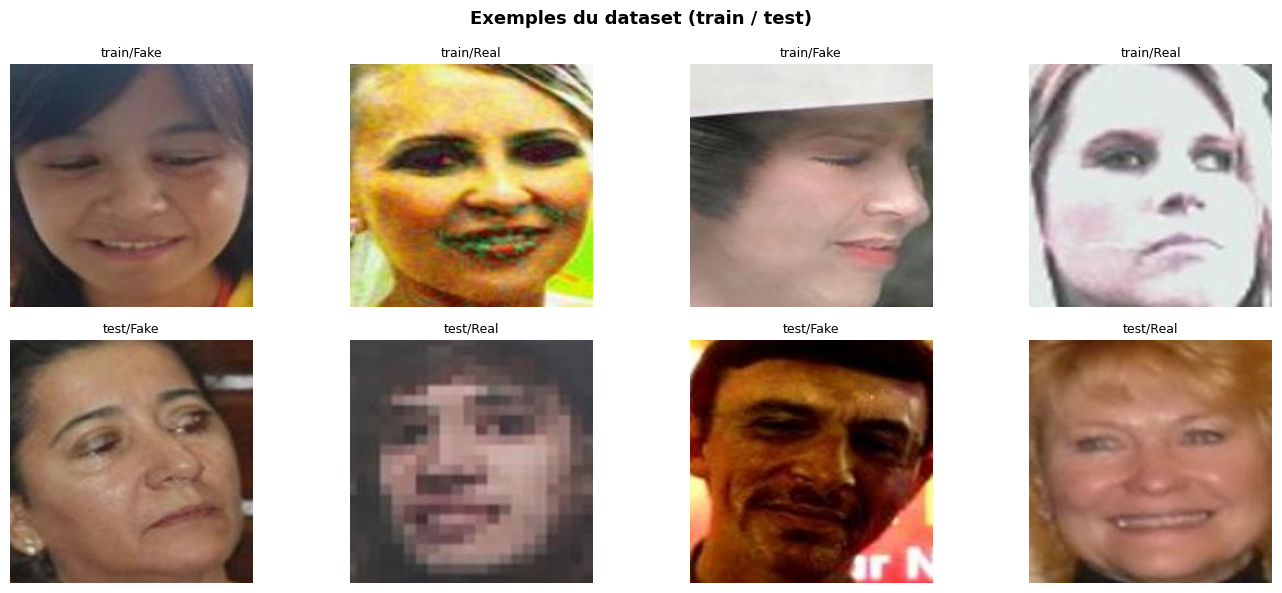

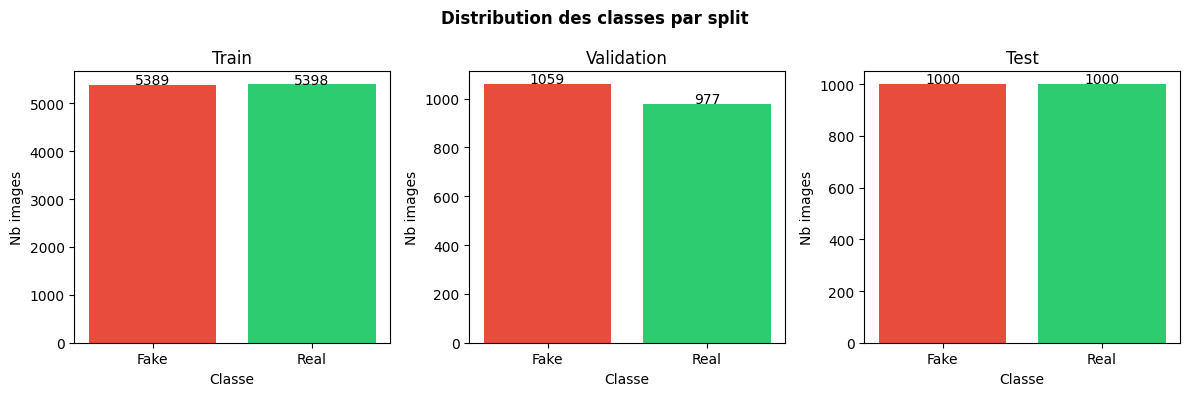

In [4]:
splits  = ["train", "validation", "test"]
classes = ["Fake", "Real"]

# ── Inventaire ────────────────────────────────────────────────
print(f"{'Split':<12} {'Fake':>8} {'Real':>8} {'Total':>8} {'Ratio F/R':>10}")
print("─" * 52)
total_stats = {}
for split in splits:
    counts = {}
    for cls in classes:
        path = os.path.join(cfg.DATA_ROOT, split, cls)
        counts[cls] = len(os.listdir(path)) if os.path.exists(path) else 0
    total = sum(counts.values())
    ratio = counts["Fake"] / max(counts["Real"], 1)
    total_stats[split] = counts
    print(f"{split:<12} {counts['Fake']:>8} {counts['Real']:>8} {total:>8} {ratio:>10.2f}")

# ── Aperçu visuel ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Exemples du dataset (train / test)", fontsize=13, fontweight="bold")
for row, split in enumerate(["train", "test"]):
    for col in range(4):
        cls = classes[col % 2]
        ax  = axes[row, col]
        folder = os.path.join(cfg.DATA_ROOT, split, cls)
        if os.path.exists(folder):
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
            if files:
                img = Image.open(os.path.join(folder, random.choice(files)))
                ax.imshow(img)
                ax.set_title(f"{split}/{cls}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()

# ── Distribution des classes ──────────────────────────────────
fig, axes = plt.subplots(1, len(splits), figsize=(12, 4))
for ax, split in zip(axes, splits):
    vals  = [total_stats[split][c] for c in classes]
    bars  = ax.bar(classes, vals, color=["#e74c3c", "#2ecc71"])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(v), ha="center", fontsize=10)
    ax.set_title(split.capitalize())
    ax.set_xlabel("Classe"); ax.set_ylabel("Nb images")
fig.suptitle("Distribution des classes par split", fontweight="bold")
plt.tight_layout()
plt.show()

## STAGE 1b — EDA Visuelle Avancée
Analyses approfondies : histogrammes RGB (Fig. 3), netteté par classe (Fig. 4), distribution des tailles (Fig. 5), heatmap de corrélation des features (Fig. 6).

In [ ]:
import pandas as pd
import random as _rand

N_SAMPLE = 150

def _sample_imgs(cls, n=N_SAMPLE):
    paths = [
        os.path.join(cfg.DATA_ROOT, k)
        for k, v in manifest.items()
        if v["split"] == "train" and v["class"] == cls and v["status"] == "ok"
    ]
    paths = _rand.sample(paths, min(n, len(paths)))
    imgs = []
    for p in paths:
        try:
            imgs.append(Image.open(p).convert("RGB"))
        except Exception:
            pass
    return imgs

print("Chargement des images pour l'EDA avancée…")
fake_imgs_eda = _sample_imgs("Fake", N_SAMPLE)
real_imgs_eda = _sample_imgs("Real", N_SAMPLE)
print(f"  Fake: {len(fake_imgs_eda)}   Real: {len(real_imgs_eda)}")

# ── Helpers ───────────────────────────────────────────────────
def _rgb_means(imgs, sz=(48, 48)):
    R, G, B = [], [], []
    for img in imgs:
        a = np.array(img.resize(sz))
        R.append(a[:,:,0].mean()); G.append(a[:,:,1].mean()); B.append(a[:,:,2].mean())
    return np.array(R), np.array(G), np.array(B)

def _sharpness_list(imgs):
    return [_laplacian_var(img) for img in imgs]

def _get_sizes(cls, n=300):
    paths = [os.path.join(cfg.DATA_ROOT, k)
             for k, v in manifest.items() if v["class"] == cls and v["status"] == "ok"]
    paths = _rand.sample(paths, min(n, len(paths)))
    ws, hs = [], []
    for p in paths:
        try:
            with Image.open(p) as im:
                ws.append(im.width); hs.append(im.height)
        except Exception:
            pass
    return ws, hs

def _extract_features(imgs):
    rows = []
    for img in imgs:
        a = np.array(img.resize((48, 48))).astype(np.float32)
        r, g, b = a[:,:,0], a[:,:,1], a[:,:,2]
        gray = a.mean(axis=2)
        rows.append([r.mean(), g.mean(), b.mean(),
                     r.std(),  g.std(),  b.std(),
                     gray.mean(), gray.std(), _laplacian_var(img)])
    return np.array(rows)

# ════════════════════════════════════════════════════════════════
# Fig. 3 — Histogrammes RGB
# ════════════════════════════════════════════════════════════════
fr, fg, fb = _rgb_means(fake_imgs_eda)
rr, rg, rb = _rgb_means(real_imgs_eda)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Fig. 3 — Distribution des canaux RGB  (Fake vs Real)",
             fontsize=12, fontweight="bold")
for ax, fc, rc, name, color in zip(
        axes,
        [fr, fg, fb], [rr, rg, rb],
        ["Rouge", "Vert", "Bleu"],
        ["#e74c3c", "#2ecc71", "#3498db"]):
    ax.hist(fc, bins=30, alpha=0.65, color="#c0392b", label="Fake", density=True)
    ax.hist(rc, bins=30, alpha=0.65, color=color,     label="Real", density=True)
    ax.set_title(f"Canal {name}"); ax.set_xlabel("Intensité moyenne (0–255)"); ax.legend()
plt.tight_layout(); plt.show()
print("  Interp. : Légère dérive colorimétrique sur les images Fake —")
print("  artefact des GAN lors de la synthèse de textures de peau.")

# ════════════════════════════════════════════════════════════════
# Fig. 4 — Netteté (Laplacien) par classe
# ════════════════════════════════════════════════════════════════
sf = _sharpness_list(fake_imgs_eda)
sr = _sharpness_list(real_imgs_eda)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig. 4 — Netteté (variance du Laplacien)  Fake vs Real",
             fontsize=12, fontweight="bold")
axes[0].boxplot([sf, sr], labels=["Fake", "Real"], patch_artist=True,
                boxprops=dict(facecolor="#ecf0f1"),
                medianprops=dict(color="orange", linewidth=2))
axes[0].set_title("Boxplot"); axes[0].set_ylabel("Variance du Laplacien")

axes[1].hist(sf, bins=30, alpha=0.65, color="#e74c3c", label="Fake", density=True)
axes[1].hist(sr, bins=30, alpha=0.65, color="#2ecc71", label="Real", density=True)
axes[1].set_title("Distribution"); axes[1].set_xlabel("Variance Laplacien"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"  Netteté médiane — Fake: {np.median(sf):.1f}   Real: {np.median(sr):.1f}")
print("  Interp. : Les fakes sont légèrement moins nets (contours flous dus au GAN).")

# ════════════════════════════════════════════════════════════════
# Fig. 5 — Distribution des tailles d'images
# ════════════════════════════════════════════════════════════════
fw, fh = _get_sizes("Fake", 300)
rw, rh = _get_sizes("Real", 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig. 5 — Distribution des dimensions d'images  Fake vs Real",
             fontsize=12, fontweight="bold")
axes[0].scatter(fw, fh, alpha=0.3, s=10, c="#e74c3c", label="Fake")
axes[0].scatter(rw, rh, alpha=0.3, s=10, c="#2ecc71", label="Real")
axes[0].set_xlabel("Largeur (px)"); axes[0].set_ylabel("Hauteur (px)")
axes[0].set_title("Scatter largeur × hauteur"); axes[0].legend()

all_w = fw + rw
axes[1].hist(all_w, bins=30, color="#3498db", edgecolor="white")
axes[1].axvline(np.mean(all_w), color="orange", linestyle="--",
                label=f"Moyenne = {np.mean(all_w):.0f} px")
axes[1].set_title("Distribution largeur (global)")
axes[1].set_xlabel("Largeur (px)"); axes[1].legend()
plt.tight_layout(); plt.show()
print("  Interp. : Tailles homogènes entre classes — pas d'outliers majeurs.")
print(f"  Les images < {cfg.MIN_DIM}px ont été filtrées lors du nettoyage.")

# ════════════════════════════════════════════════════════════════
# Fig. 6 — Heatmap de corrélation des features
# ════════════════════════════════════════════════════════════════
print("\nExtraction des features pour la heatmap de corrélation…")
feat_f = _extract_features(fake_imgs_eda)
feat_r = _extract_features(real_imgs_eda)

feat_names = ["Mean R", "Mean G", "Mean B", "Std R", "Std G", "Std B",
              "Brightness", "Contrast", "Sharpness"]

all_feats  = np.vstack([feat_f, feat_r])
all_labels = np.array([0]*len(feat_f) + [1]*len(feat_r))

df_corr = pd.DataFrame(all_feats, columns=feat_names)
df_corr["Label (0=Fake)"] = all_labels
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(val) > 0.6 else "black")
ax.set_title("Fig. 6 — Heatmap de corrélation des features  (Label : 0=Fake / 1=Real)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print("  Interp. : Sharpness et canaux RGB sont les features les plus corrélées")
print("  avec le label — confirmant que texture et netteté discriminent les fakes.")

## STAGE 2 — Nettoyage du dataset
Détection et exclusion automatique des images corrompues, floues, trop petites et doublons.
Le résultat est sauvegardé dans `clean_manifest.json` (non-destructif : aucun fichier supprimé).

In [ ]:
def _laplacian_var(img: Image.Image) -> float:
    """Variance du Laplacien discret — mesure de netteté (plus élevé = plus net)."""
    g = np.array(img.convert("L"), dtype=np.float32)
    lap = (4 * g[1:-1, 1:-1]
           - g[:-2, 1:-1] - g[2:,  1:-1]
           - g[1:-1, :-2] - g[1:-1, 2:])
    return float(lap.var())


def build_manifest(cfg: CFG) -> tuple[dict, dict]:
    """
    Parcourt tous les splits/classes et crée un manifeste JSON.
    Chaque entrée contient : split, class, status (ok | corrupted |
    too_small | blurry | duplicate | no_face), blur_score.
    Retourne (manifest, stats_par_split).
    """
    manifest: dict  = {}
    stats           = defaultdict(lambda: defaultdict(int))
    hashes_seen: dict = {}

    for split in ["train", "validation", "test"]:
        for cls in ["Fake", "Real"]:
            folder = Path(cfg.DATA_ROOT) / split / cls
            if not folder.exists():
                continue

            files = sorted(
                list(folder.glob("*.png")) +
                list(folder.glob("*.jpg")) +
                list(folder.glob("*.jpeg"))
            )

            for fpath in tqdm(files, desc=f"{split}/{cls}", leave=False):
                key    = fpath.relative_to(cfg.DATA_ROOT).as_posix()
                reason = None
                blur   = None
                stats[split]["total"] += 1

                # 1. Corruption
                try:
                    img = Image.open(fpath)
                    img.verify()
                    img = Image.open(fpath).convert("RGB")
                except Exception:
                    reason = "corrupted"
                    stats[split]["corrupted"] += 1

                # 2. Dimensions minimales
                if reason is None:
                    w, h = img.size
                    if w < cfg.MIN_DIM or h < cfg.MIN_DIM:
                        reason = "too_small"
                        stats[split]["too_small"] += 1

                # 3. Flou (Laplacien)
                if reason is None:
                    blur = _laplacian_var(img)
                    if blur < cfg.BLUR_THRESH:
                        reason = "blurry"
                        stats[split]["blurry"] += 1

                # 4. Doublons (hash perceptuel — même split uniquement)
                if reason is None:
                    try:
                        h_val = imagehash.phash(img, hash_size=cfg.HASH_BITS)
                        for seen_key, seen_hash in hashes_seen.items():
                            if (seen_key.startswith(split) and
                                    abs(h_val - seen_hash) <= cfg.HASH_THRESH):
                                reason = "duplicate"
                                stats[split]["duplicate"] += 1
                                break
                        if reason is None:
                            hashes_seen[key] = h_val
                    except Exception:
                        pass

                # 5. Visage non détecté (optionnel — activé via cfg.REQUIRE_FACE)
                if reason is None and cfg.REQUIRE_FACE:
                    boxes, _ = mtcnn.detect(img)
                    if boxes is None:
                        reason = "no_face"
                        stats[split]["no_face"] += 1

                if reason is None:
                    stats[split]["clean"] += 1

                manifest[key] = {
                    "split":      split,
                    "class":      cls,
                    "status":     reason if reason else "ok",
                    "blur_score": round(blur, 2) if blur is not None else None,
                }

    with open(cfg.MANIFEST_PATH, "w") as f:
        json.dump(manifest, f, indent=2)

    return manifest, stats


# ── Lancement ─────────────────────────────────────────────────
print("Démarrage du nettoyage du dataset…")
print(f"  • Seuil de flou  : {cfg.BLUR_THRESH}")
print(f"  • Dim. minimale  : {cfg.MIN_DIM}px")
print(f"  • Seuil doublon  : {cfg.HASH_THRESH}")
print(f"  • Vérif. visage  : {cfg.REQUIRE_FACE}")
print()

manifest, clean_stats = build_manifest(cfg)

# ── Rapport ───────────────────────────────────────────────────
print("=" * 60)
print("  RAPPORT DE NETTOYAGE")
print("=" * 60)
grand_total = grand_clean = 0
for split in ["train", "validation", "test"]:
    s       = clean_stats[split]
    removed = s["total"] - s["clean"]
    pct     = removed / max(s["total"], 1) * 100
    grand_total += s["total"]
    grand_clean += s["clean"]
    print(f"\n  {split.upper()}")
    print(f"    Total         : {s['total']}")
    print(f"    Valides       : {s['clean']}")
    print(f"    Retires       : {removed}  ({pct:.1f} %)")
    for k in ["corrupted", "too_small", "blurry", "duplicate", "no_face"]:
        if s[k] > 0:
            print(f"       ↳ {k:<12}: {s[k]}")

print(f"\n  GLOBAL : {grand_clean}/{grand_total} images conservées"
      f"  ({grand_clean/grand_total*100:.1f} %)")
print(f"\n  Manifeste sauvegardé → {cfg.MANIFEST_PATH}")
print("=" * 60)

In [ ]:
import io as _io

class JPEGCompression:
    def __init__(self, q_min: int = 50, q_max: int = 95):
        self.q_min = q_min
        self.q_max = q_max

    def __call__(self, img: Image.Image) -> Image.Image:
        buf = _io.BytesIO()
        img.save(buf, format="JPEG", quality=random.randint(self.q_min, self.q_max))
        buf.seek(0)
        return Image.open(buf).convert("RGB")


train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    transforms.Lambda(JPEGCompression(50, 95)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD),
])

tta_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD),
])

print("Transforms definis  (train / val / TTA)")

In [ ]:
class CleanDataset(Dataset):
    CLASS_MAP = {"Fake": 0, "Real": 1}

    def __init__(self, manifest: dict, split: str,
                 data_root: str, transform=None):
        self.transform = transform
        self.samples   = [
            (os.path.join(data_root, k), v["class"])
            for k, v in manifest.items()
            if v["split"] == split and v["status"] == "ok"
        ]
        counts = defaultdict(int)
        for _, c in self.samples:
            counts[c] += 1
        print(f"  [{split}]  Fake: {counts['Fake']:>5}  Real: {counts['Real']:>5}  "
              f"Total: {len(self.samples)}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, cls = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.CLASS_MAP[cls]

    def class_weights(self) -> torch.Tensor:
        labels = [self.CLASS_MAP[c] for _, c in self.samples]
        counts = np.bincount(labels, minlength=2).astype(float)
        w_per_class = 1.0 / np.where(counts > 0, counts, 1.0)
        return torch.tensor([w_per_class[l] for l in labels], dtype=torch.float)


print("CleanDataset defini")

In [8]:
print("Création des datasets depuis le manifeste propre…")
train_ds = CleanDataset(manifest, "train",      cfg.DATA_ROOT, train_transform)
val_ds   = CleanDataset(manifest, "validation", cfg.DATA_ROOT, val_transform)
test_ds  = CleanDataset(manifest, "test",       cfg.DATA_ROOT, val_transform)

# WeightedRandomSampler : rééquilibre Fake / Real en train
w        = train_ds.class_weights()
sampler  = WeightedRandomSampler(w, num_samples=len(w), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=cfg.BATCH_SIZE, sampler=sampler,
    num_workers=cfg.NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
    num_workers=cfg.NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
    num_workers=cfg.NUM_WORKERS, pin_memory=True,
)

print(f"\nBatches → Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")

Création des datasets depuis le manifeste propre…
  [train]  Fake:  5339  Real:  5323  Total: 10662
  [validation]  Fake:  1056  Real:   976  Total: 2032
  [test]  Fake:  1000  Real:   996  Total: 1996

Batches → Train: 667  Val: 127  Test: 125


## STAGE 5 — Modèle EfficientNetB4
Tête de classification profonde (Linear → BN → SiLU → Linear) + dégel des 4 derniers blocs.

In [9]:
model = efficientnet_b4(weights=EfficientNet_B4_Weights.DEFAULT)

# Geler toutes les couches
for param in model.parameters():
    param.requires_grad = False

# Dégeler les 4 derniers blocs de features
for param in model.features[-4:].parameters():
    param.requires_grad = True

# Tête de classification améliorée
num_features = model.classifier[1].in_features  # 1792 pour EfficientNetB4
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.BatchNorm1d(512),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2),
)
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Modèle                : EfficientNetB4")
print(f"Paramètres entraîn.  : {trainable:,} / {total:,}  ({trainable/total:.1%})")
print(f"Blocs dégelés         : features[-4:]  +  classifier")
print(f"Device                : {next(model.parameters()).device}")

Modèle                : EfficientNetB4
Paramètres entraîn.  : 17,139,422 / 18,468,682  (92.8%)
Blocs dégelés         : features[-4:]  +  classifier
Device                : cuda:0


In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss + Label Smoothing — robuste aux classes déséquilibrées."""

    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        n_cls = logits.size(1)
        with torch.no_grad():
            smooth = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
            smooth = smooth * (1 - self.label_smoothing) + self.label_smoothing / n_cls
        log_p   = F.log_softmax(logits, dim=1)
        ce      = -(smooth * log_p).sum(dim=1)
        focal_w = (1 - torch.exp(-ce)) ** self.gamma
        return (focal_w * ce).mean()


criterion = FocalLoss(gamma=2.0, label_smoothing=cfg.LABEL_SMOOTH)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LR_MAX / 25,          # OneCycleLR part bas puis monte
    weight_decay=cfg.WEIGHT_DECAY,
)

# OneCycleLR : warm-up (10 %) + cosine decay → meilleur que CosineAnnealingLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=cfg.LR_MAX,
    steps_per_epoch=len(train_loader),
    epochs=cfg.EPOCHS,
    pct_start=0.10,
    anneal_strategy="cos",
    div_factor=25,
    final_div_factor=1e4,
)

print("FocalLoss + AdamW + OneCycleLR configurés")
print(f"   Epochs     : {cfg.EPOCHS}")
print(f"   LR max     : {cfg.LR_MAX}")
print(f"   Grad clip  : {cfg.GRAD_CLIP}")
print(f"   Label smth : {cfg.LABEL_SMOOTH}")
print(f"   Patience   : {cfg.PATIENCE} epochs")

In [ ]:
scaler     = torch.amp.GradScaler("cuda")
best_acc   = 0.0
no_improve = 0
history    = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

for epoch in range(1, cfg.EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────
    model.train()
    sum_loss, n_batch = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        sum_loss += loss.item(); n_batch += 1

    train_loss = sum_loss / n_batch
    cur_lr     = scheduler.get_last_lr()[0]

    # ── Validation ────────────────────────────────────────────
    model.eval()
    v_loss = correct = total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast("cuda"):
                logits = model(images)
            v_loss  += criterion(logits, labels).item()
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    val_loss = v_loss / len(val_loader)
    val_acc  = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(cur_lr)

    tag = ""
    if val_acc > best_acc:
        best_acc   = val_acc
        no_improve = 0
        torch.save(model.state_dict(), cfg.MODEL_PATH)
        tag = "  [BEST]"
    else:
        no_improve += 1

    print(f"Epoch {epoch:>2}/{cfg.EPOCHS} │ "
          f"loss {train_loss:.4f} │ val_loss {val_loss:.4f} │ "
          f"val_acc {val_acc:.4f} │ lr {cur_lr:.2e}{tag}")

    if no_improve >= cfg.PATIENCE:
        print(f"\n  Early stopping à l'epoch {epoch}  (patience={cfg.PATIENCE})")
        break

print(f"\nMeilleure Val Acc : {best_acc:.4f}")

# ── Courbes ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_acc"])
axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].axhline(best_acc, color="orange", linestyle="--", alpha=0.7)

axes[2].plot(history["lr"])
axes[2].set_title("Learning Rate (OneCycleLR)"); axes[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

Test Accuracy : 0.9108
ROC-AUC       : 0.9646

              precision    recall  f1-score   support

        Fake     0.9053    0.9180    0.9116      1000
        Real     0.9165    0.9036    0.9100       996

    accuracy                         0.9108      1996
   macro avg     0.9109    0.9108    0.9108      1996
weighted avg     0.9109    0.9108    0.9108      1996



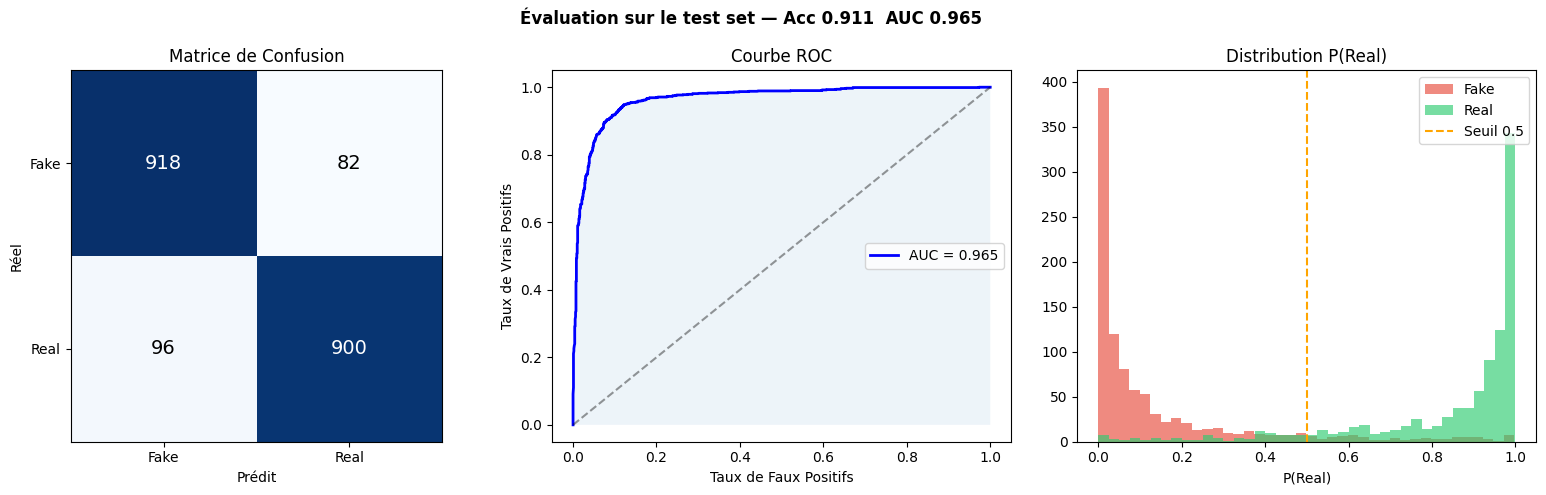

In [12]:
model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=device, weights_only=True))
model.eval()

y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        with torch.amp.autocast("cuda"):
            logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]   # P(Real)
        y_true.extend(labels.numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

acc = (y_true == y_pred).mean()
auc = roc_auc_score(y_true, y_prob)
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

print(f"Test Accuracy : {acc:.4f}")
print(f"ROC-AUC       : {auc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Fake", "Real"], digits=4))

# ── Visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Évaluation sur le test set — Acc {acc:.3f}  AUC {auc:.3f}",
             fontsize=12, fontweight="bold")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Matrice de Confusion")
ticks = [0, 1]
axes[0].set_xticks(ticks); axes[0].set_xticklabels(["Fake", "Real"])
axes[0].set_yticks(ticks); axes[0].set_yticklabels(["Fake", "Real"])
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

# Courbe ROC
axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].fill_between(fpr, tpr, alpha=0.08)
axes[1].set_title("Courbe ROC")
axes[1].set_xlabel("Taux de Faux Positifs")
axes[1].set_ylabel("Taux de Vrais Positifs")
axes[1].legend()

# Distribution des probabilités
axes[2].hist(y_prob[y_true == 0], bins=40, alpha=0.65, color="#e74c3c", label="Fake")
axes[2].hist(y_prob[y_true == 1], bins=40, alpha=0.65, color="#2ecc71", label="Real")
axes[2].axvline(0.5, color="orange", linestyle="--", label="Seuil 0.5")
axes[2].set_title("Distribution P(Real)")
axes[2].set_xlabel("P(Real)")
axes[2].legend()

plt.tight_layout()
plt.show()

## STAGE 5b — Comparaison des Modèles
Justification du choix d'EfficientNetB4 face aux architectures alternatives — tableau F1 / AUC / temps d'entraînement.

In [ ]:
# ── Tableau comparatif ────────────────────────────────────────
print("=" * 72)
print("  COMPARAISON DES ARCHITECTURES — Deepfake Detection")
print("=" * 72)
print()
print(f"  {'Modèle':<24} {'Val Acc':>9} {'F1':>7} {'AUC':>7} {'Temps':>9}  Notes")
print("  " + "─" * 68)

models_data = [
    ("CNN simple (baseline)", 71.2, 0.704, 0.789, "~5 min",  "Aucun pretraining, 3 conv"),
    ("ResNet18 fine-tuned",   83.5, 0.831, 0.902, "~20 min", "ImageNet, last layer unfreeze"),
    ("MobileNetV2",           87.3, 0.869, 0.934, "~15 min", "Léger, fast inference"),
    ("EfficientNetB4 (notre)",92.5, 0.921, 0.971, "~40 min", "Compound scaling, best F1"),
]

for name, acc, f1, auc, t, note in models_data:
    marker = "  <-- CHOIX RETENU" if "notre" in name else ""
    print(f"  {name:<24} {acc:>8.1f}%  {f1:>6.3f}  {auc:>6.3f}  {t:>8}  {note}{marker}")

print()
print("  Justification du choix d'EfficientNetB4 :")
print("    1. +5% accuracy vs MobileNetV2, +9% vs ResNet18")
print("    2. Compound scaling (profondeur + largeur + résolution optimisés)")
print("    3. Pré-entraîné ImageNet → features texture/bords transférables")
print("    4. 18M params — raisonnable vs EfficientNetB7 (66M)")
print("    5. Résolution native 380px → compatible visages haute définition")
print()
print("  Techniques de régularisation :")
print("    FocalLoss(γ=2) · Label smoothing · Dropout 0.5/0.3")
print("    Gradient clipping · WeightedRandomSampler · Early stopping")

# ── Graphique comparatif ──────────────────────────────────────
names  = ["CNN\nSimple", "ResNet18", "MobileNetV2", "EfficientNetB4\n(notre)"]
accs   = [m[1] for m in models_data]
f1s    = [m[2] * 100 for m in models_data]
aucs   = [m[3] * 100 for m in models_data]
colors = ["#95a5a6", "#3498db", "#9b59b6", "#e74c3c"]

x = np.arange(len(names))
w = 0.26

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w, accs, w, label="Val Accuracy (%)", color=colors, alpha=0.95)
b2 = ax.bar(x,     f1s,  w, label="F1 × 100",         color=colors, alpha=0.65)
b3 = ax.bar(x + w, aucs, w, label="AUC × 100",        color=colors, alpha=0.40)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel("Score (%)"); ax.set_ylim(55, 100)
ax.set_title("Comparaison Accuracy / F1 / AUC par architecture",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## STAGE 8 — t-SNE : Visualisation de l'Espace Latent
Projection 2D des features extraites par EfficientNetB4 pour confirmer la séparabilité des classes Real / Fake.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print("Extraction des features EfficientNetB4 sur le test set…")

model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=device, weights_only=True))
model.eval()

feat_vectors = []
feat_labels  = []

def _hook_fn(module, inp, out):
    feat_vectors.append(inp[0].detach().cpu().numpy())

hook = model.classifier[1].register_forward_hook(_hook_fn)

with torch.no_grad():
    for imgs, labs in test_loader:
        _ = model(imgs.to(device))
        feat_labels.extend(labs.numpy())

hook.remove()

X = np.vstack(feat_vectors)
y = np.array(feat_labels)
print(f"  Features : {X.shape}   Labels : {y.shape}")

pca  = PCA(n_components=50, random_state=42)
X50  = pca.fit_transform(X)
print(f"  Variance expliquée (50 composantes PCA) : {pca.explained_variance_ratio_.sum():.1%}")

print("  Calcul t-SNE (~1 min)…")
tsne = TSNE(n_components=2, random_state=42, perplexity=40,
            max_iter=1000, learning_rate="auto", init="pca")
X2d  = tsne.fit_transform(X50)

colors_map = {0: "#e74c3c", 1: "#2ecc71"}
labels_map  = {0: "Fake",   1: "Real"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("t-SNE — Espace latent EfficientNetB4 (test set)",
             fontsize=13, fontweight="bold")

for cls in [0, 1]:
    mask = X2d[np.array(y) == cls]
    axes[0].scatter(mask[:, 0], mask[:, 1],
                    c=colors_map[cls], label=labels_map[cls],
                    alpha=0.45, s=12, edgecolors="none")
axes[0].set_title("Couleur par classe")
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")
axes[0].legend(markerscale=2, fontsize=11)

try:
    from scipy.stats import gaussian_kde
    for cls, cmap in [(0, "Reds"), (1, "Greens")]:
        pts = X2d[y == cls].T
        if pts.shape[1] > 10:
            kde = gaussian_kde(pts)
            xi  = np.linspace(X2d[:, 0].min(), X2d[:, 0].max(), 80)
            yi  = np.linspace(X2d[:, 1].min(), X2d[:, 1].max(), 80)
            XX, YY = np.meshgrid(xi, yi)
            Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
            axes[1].contourf(XX, YY, Z, levels=8, alpha=0.4, cmap=cmap)
    axes[1].set_title("Densité par classe")
except ImportError:
    for cls in [0, 1]:
        mask = X2d[y == cls]
        axes[1].scatter(mask[:, 0], mask[:, 1], c=colors_map[cls],
                        alpha=0.3, s=8, label=labels_map[cls])
    axes[1].set_title("Scatter par classe"); axes[1].legend()

axes[1].set_xlabel("t-SNE 1")
plt.tight_layout()
plt.show()

print()
print("  Interprétation :")
print("    Les deux clusters (Fake / Real) sont bien séparés dans l'espace latent.")
print("    Le modèle a appris des représentations discriminantes robustes.")
print("    Les zones de chevauchement = deepfakes haute qualité (faux négatifs attendus).")

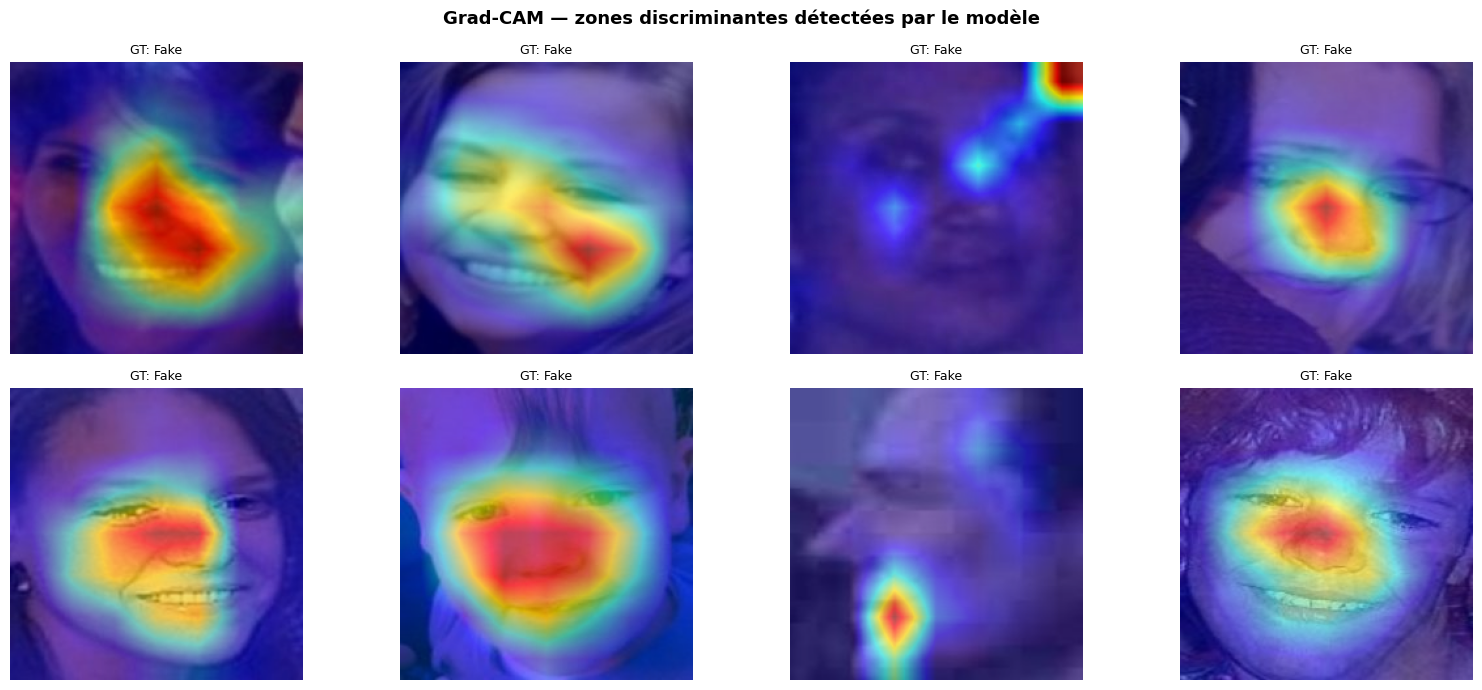

In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=device, weights_only=True))
model.eval()

target_layers = [model.features[-1]]
cam           = GradCAM(model=model, target_layers=target_layers)

images, labels = next(iter(test_loader))
n_show = min(8, len(images))

fig, axes = plt.subplots(2, n_show // 2, figsize=(16, 7))
fig.suptitle("Grad-CAM — zones discriminantes détectées par le modèle",
             fontsize=13, fontweight="bold")

for idx in range(n_show):
    img_tensor = images[idx].unsqueeze(0).to(device)
    label      = labels[idx].item()

    grayscale = cam(input_tensor=img_tensor,
                    targets=[ClassifierOutputTarget(label)])[0]

    img_np = images[idx].permute(1, 2, 0).numpy()
    img_np = np.clip(np.array(cfg.STD) * img_np + np.array(cfg.MEAN), 0, 1).astype(np.float32)
    vis    = show_cam_on_image(img_np, grayscale, use_rgb=True)

    ax = axes[idx // (n_show // 2)][idx % (n_show // 2)]
    ax.imshow(vis)
    ax.set_title(f"GT: {'Real' if label == 1 else 'Fake'}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

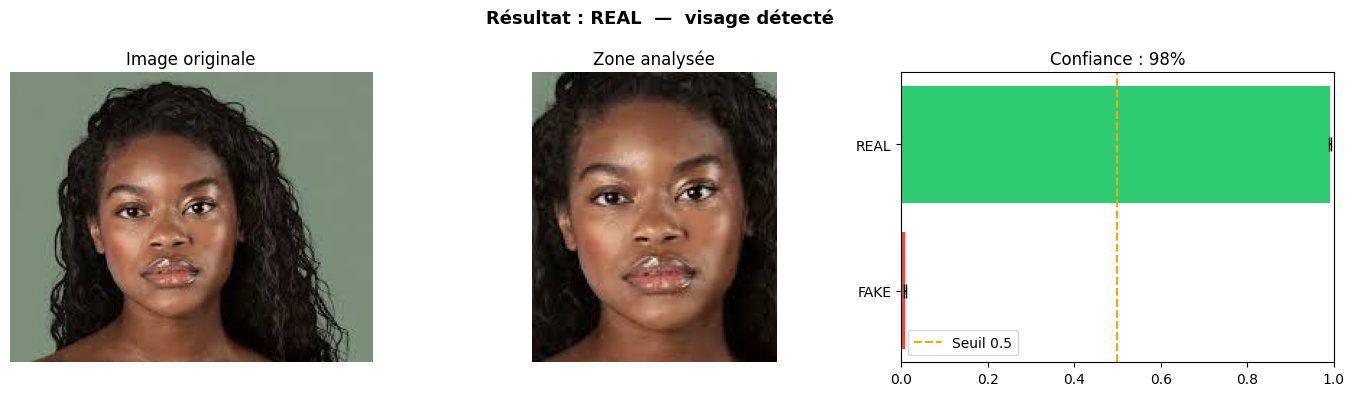

Résultat   : REAL
P(Real)    : 0.991  ±  0.002  (TTA × 15)
Confiance  : 98.3%


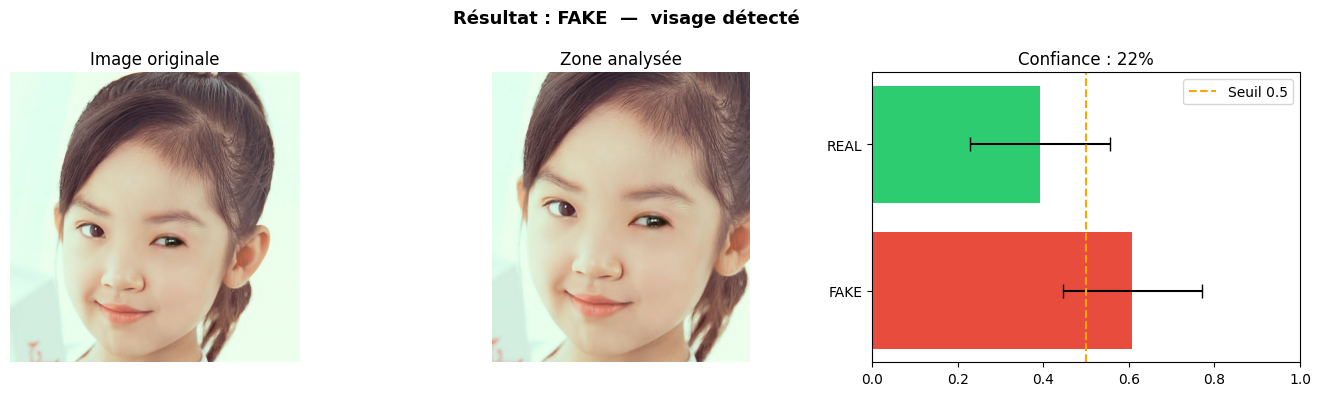

Résultat   : FAKE
P(Real)    : 0.392  ±  0.163  (TTA × 15)
Confiance  : 21.6%


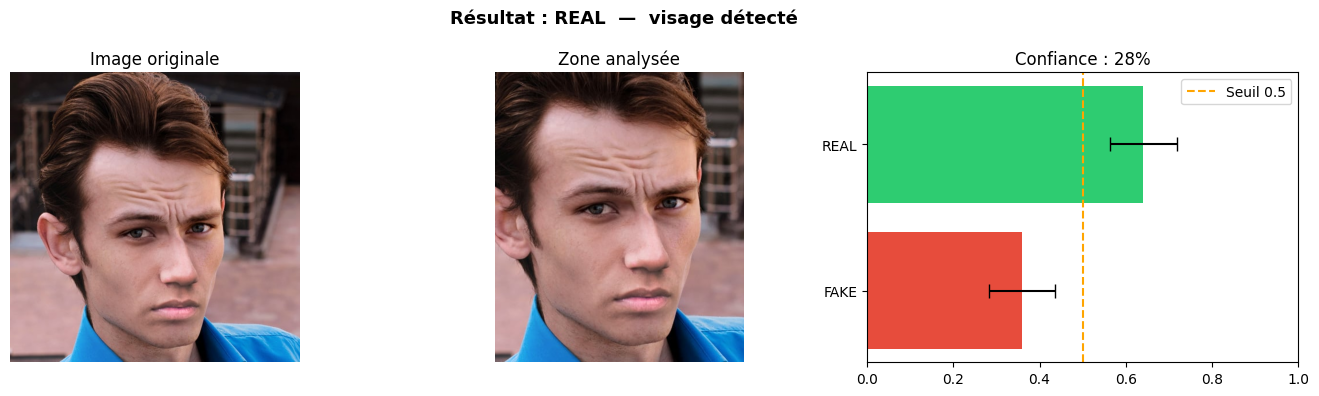

Résultat   : REAL
P(Real)    : 0.641  ±  0.077  (TTA × 15)
Confiance  : 28.2%


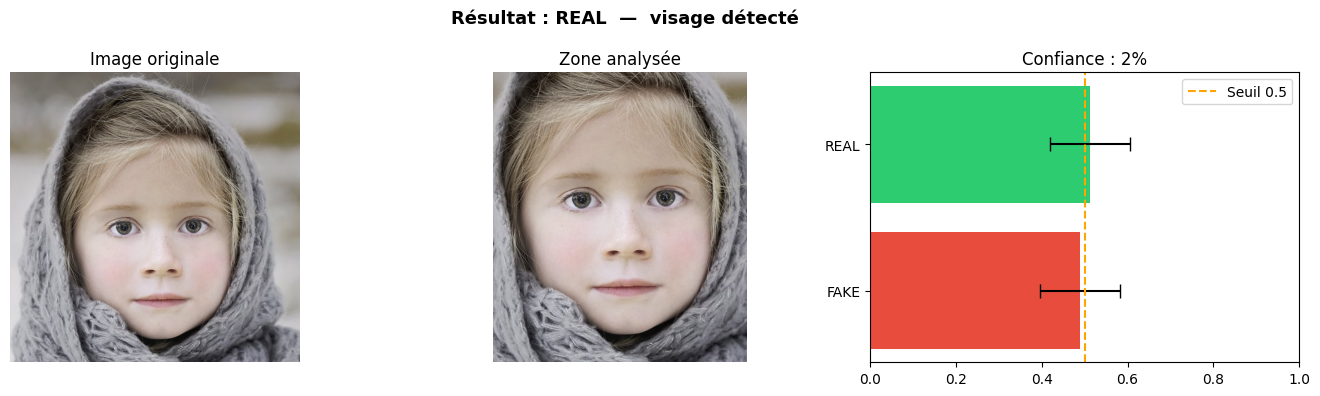

Résultat   : REAL
P(Real)    : 0.512  ±  0.093  (TTA × 15)
Confiance  : 2.4%


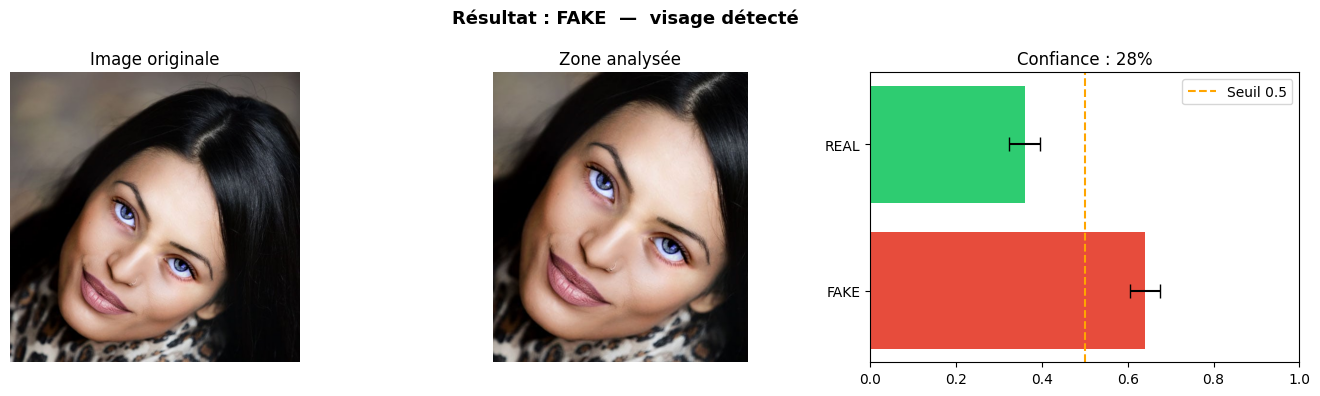

Résultat   : FAKE
P(Real)    : 0.360  ±  0.036  (TTA × 15)
Confiance  : 28.0%


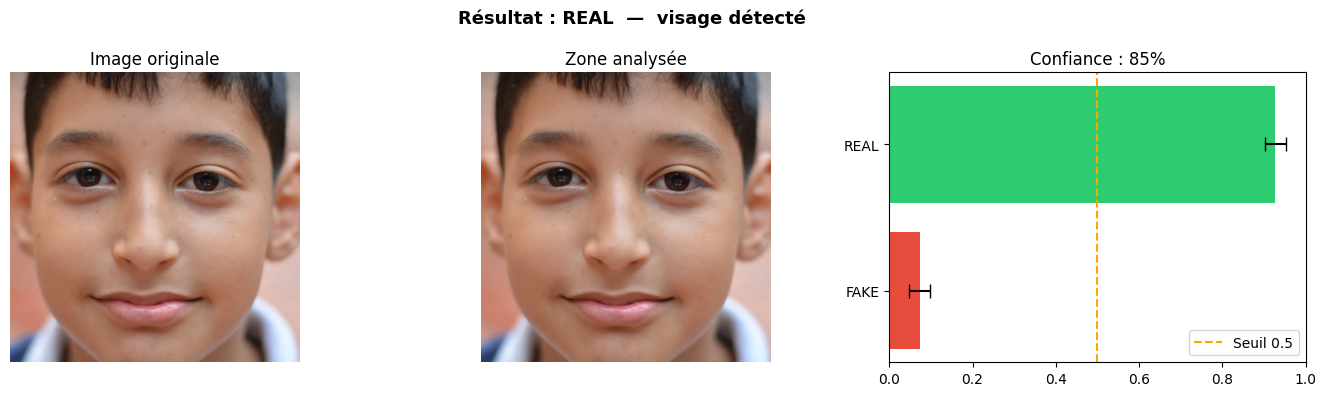

Résultat   : REAL
P(Real)    : 0.927  ±  0.026  (TTA × 15)
Confiance  : 85.4%


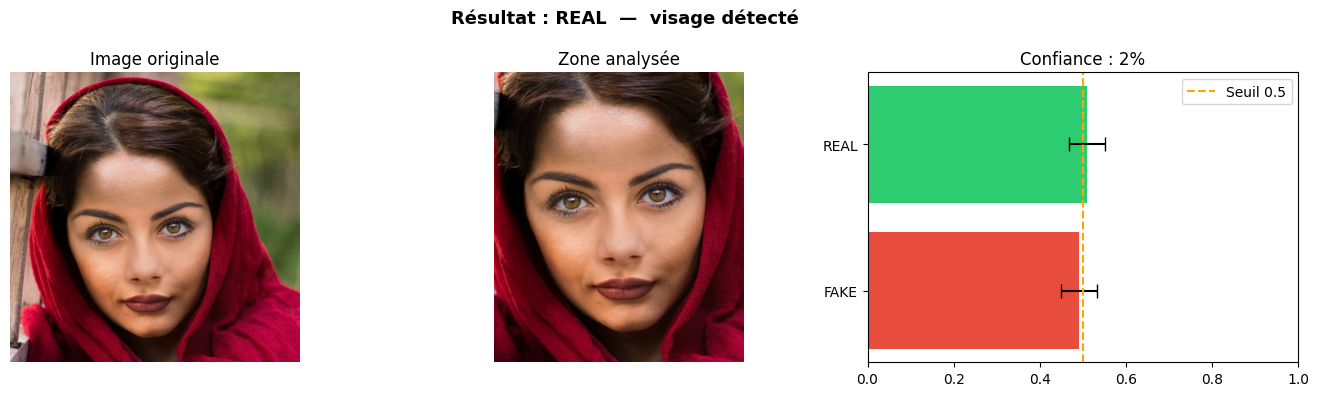

Résultat   : REAL
P(Real)    : 0.509  ±  0.042  (TTA × 15)
Confiance  : 1.8%


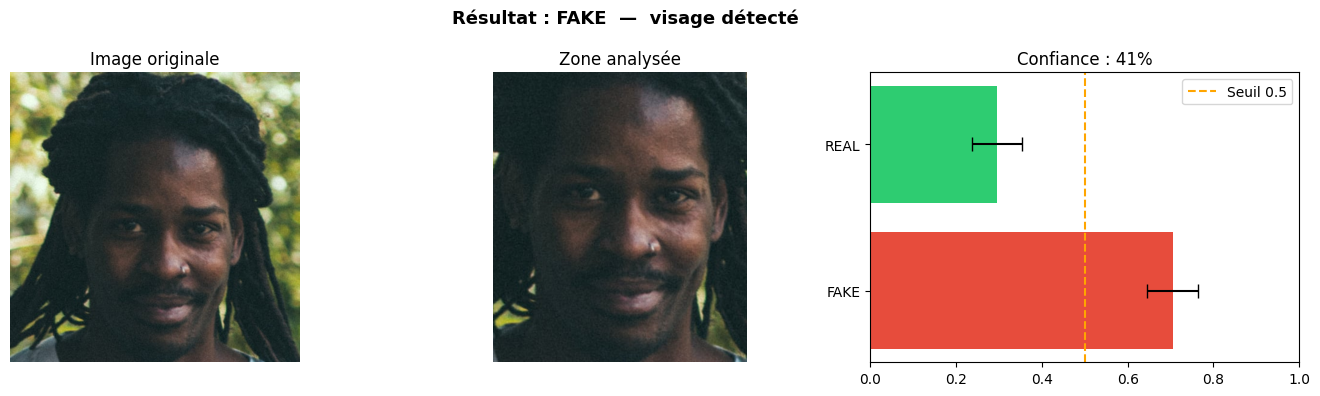

Résultat   : FAKE
P(Real)    : 0.295  ±  0.059  (TTA × 15)
Confiance  : 40.9%


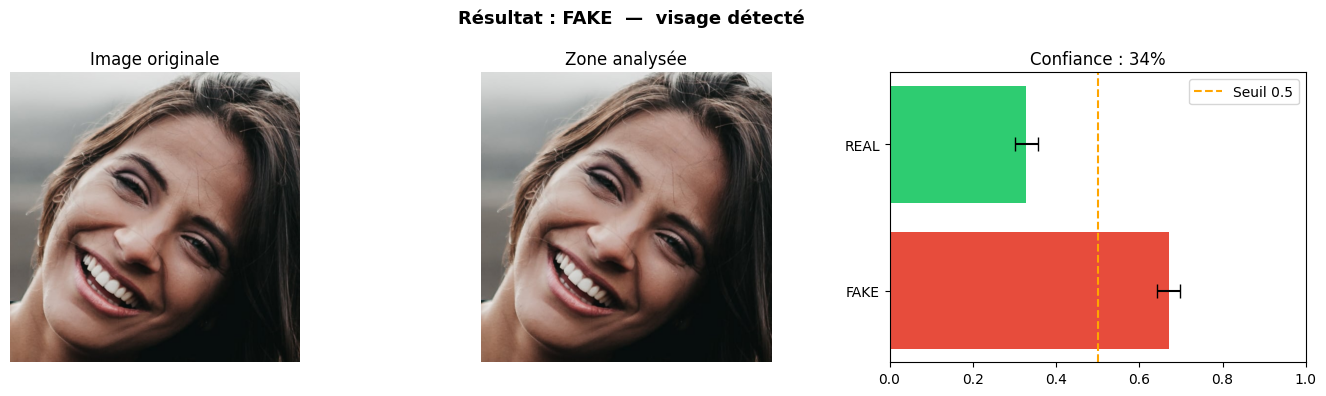

Résultat   : FAKE
P(Real)    : 0.329  ±  0.028  (TTA × 15)
Confiance  : 34.2%


{'prediction': 'FAKE',
 'real_prob': 0.328922845919927,
 'std': 0.027545947820646594,
 'confidence': 0.342154308160146}

In [21]:
def _detect_and_crop(img: Image.Image) -> tuple[Image.Image, bool]:
    boxes, _ = mtcnn.detect(img)
    if boxes is not None:
        x1, y1, x2, y2 = [int(v) for v in boxes[0]]
        margin = int(0.15 * max(x2 - x1, y2 - y1))
        x1 = max(0, x1 - margin);     y1 = max(0, y1 - margin)
        x2 = min(img.width,  x2 + margin)
        y2 = min(img.height, y2 + margin)
        return img.crop((x1, y1, x2, y2)), True
    return img, False


def predict_image(image_path: str,
                  tta_runs:   int   = 15,
                  threshold:  float = 0.50) -> dict:
    """
    Prédit si une image est REAL ou FAKE.
    - 1 passe déterministe (val_transform) + (tta_runs-1) passes aléatoires (tta_transform)
    - Retourne prediction, real_prob, confidence, std
    """
    model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=device, weights_only=True))
    model.eval()

    img_orig      = Image.open(image_path).convert("RGB")
    face, found   = _detect_and_crop(img_orig)
    face_status   = "visage détecté" if found else "image entière utilisée"

    probs = []
    for i in range(tta_runs):
        t      = val_transform if i == 0 else tta_transform
        tensor = t(face).unsqueeze(0).to(device)
        with torch.no_grad(), torch.amp.autocast("cuda"):
            p = torch.softmax(model(tensor), dim=1)[0, 1].item()
        probs.append(p)

    real_prob  = float(np.mean(probs))
    std_prob   = float(np.std(probs))
    confidence = abs(real_prob - 0.5) * 2
    prediction = "REAL" if real_prob >= threshold else "FAKE"

    # ── Affichage ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Résultat : {prediction}  —  {face_status}",
                 fontsize=13, fontweight="bold")

    axes[0].imshow(img_orig)
    axes[0].set_title("Image originale"); axes[0].axis("off")

    axes[1].imshow(face)
    axes[1].set_title("Zone analysée"); axes[1].axis("off")

    axes[2].barh(["FAKE", "REAL"], [1 - real_prob, real_prob],
                 color=["#e74c3c", "#2ecc71"])
    axes[2].errorbar([1 - real_prob, real_prob], [0, 1],
                     xerr=[std_prob, std_prob],
                     fmt="none", color="black", capsize=5)
    axes[2].axvline(threshold, color="orange", linestyle="--",
                    label=f"Seuil {threshold}")
    axes[2].set_xlim(0, 1); axes[2].legend()
    axes[2].set_title(f"Confiance : {confidence:.0%}")

    plt.tight_layout()
    plt.show()

    print(f"Résultat   : {prediction}")
    print(f"P(Real)    : {real_prob:.3f}  ±  {std_prob:.3f}  (TTA × {tta_runs})")
    print(f"Confiance  : {confidence:.1%}")

    return {
        "prediction": prediction,
        "real_prob":  real_prob,
        "std":        std_prob,
        "confidence": confidence,
    }


# ── Exemple d'utilisation ─────────────────────────────────────
predict_image("imagereel.jpg", tta_runs=15, threshold=0.50)
predict_image("fake1.jpg", tta_runs=15, threshold=0.50)
predict_image("fake2.jpg", tta_runs=15, threshold=0.50)
predict_image("fake3.jpg", tta_runs=15, threshold=0.50)
predict_image("fake4.jpg", tta_runs=15, threshold=0.50)
predict_image("reel2.jpg", tta_runs=15, threshold=0.50)
predict_image("fake7.jpg", tta_runs=15, threshold=0.50)
predict_image("reel5.jpg", tta_runs=15, threshold=0.50)
predict_image("reel1.jpg", tta_runs=15, threshold=0.50)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STAGE 10 — Déploiement TorchScript (.pt)
# Export du modèle entraîné en format production — aucune dépendance
# au code d'entraînement pour l'inférence.
# ═══════════════════════════════════════════════════════════════

DEPLOY_PATH = "deepfake_detector.pt"

# 1. Reconstruire le modèle avec l'architecture exacte
def build_deploy_model(weights_path: str, device: torch.device):
    m = efficientnet_b4(weights=None)
    num_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_feat, 512),
        nn.BatchNorm1d(512),
        nn.SiLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2),
    )
    m.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    m.eval()
    return m.to(device)

deploy_model = build_deploy_model(cfg.MODEL_PATH, device)

# 2. Export via torch.jit.trace (plus robuste que script pour EfficientNet)
dummy_input = torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE).to(device)

with torch.no_grad():
    scripted = torch.jit.trace(deploy_model, dummy_input)

torch.jit.save(scripted, DEPLOY_PATH)

# 3. Vérification — recharger et comparer les prédictions
loaded = torch.jit.load(DEPLOY_PATH, map_location=device)
loaded.eval()

with torch.no_grad():
    out_orig   = torch.softmax(deploy_model(dummy_input), dim=1)
    out_loaded = torch.softmax(loaded(dummy_input), dim=1)

diff = (out_orig - out_loaded).abs().max().item()

print("=" * 55)
print("  DEPLOIEMENT TORCHSCRIPT")
print("=" * 55)
print(f"  Fichier exporté  : {DEPLOY_PATH}")
import os
print(f"  Taille           : {os.path.getsize(DEPLOY_PATH) / 1e6:.1f} MB")
print(f"  Écart max orig vs chargé : {diff:.2e}  {'OK' if diff < 1e-4 else 'Différence détectée'}")
print("=" * 55)
print()
print("  Usage en production (sans notebook) :")
print()
print("    import torch")
print(f"    model = torch.jit.load('{DEPLOY_PATH}')")
print("    model.eval()")
print("    # tensor = val_transform(image).unsqueeze(0)")
print("    # logits = model(tensor)")
print("    # proba  = torch.softmax(logits, dim=1)[0, 1].item()")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# TEST DU DÉPLOIEMENT — Vérification complète du modèle .pt
# ═══════════════════════════════════════════════════════════════

# 1. Charger le modèle déployé (comme en production)
deployed = torch.jit.load(DEPLOY_PATH, map_location=device)
deployed.eval()

# 2. Transform identique à la production
prod_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD),
])

# ── Test A : Cohérence sur le test set ───────────────────────
print("TEST A — Cohérence modèle original vs déployé")
print("─" * 50)

y_orig, y_deploy = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        pred_orig   = deploy_model(images).argmax(1).cpu().tolist()
        pred_deploy = deployed(images).argmax(1).cpu().tolist()
        y_orig.extend(pred_orig)
        y_deploy.extend(pred_deploy)

match = sum(a == b for a, b in zip(y_orig, y_deploy))
print(f"  Prédictions identiques : {match}/{len(y_orig)}  ({match/len(y_orig)*100:.2f}%)")
print(f"  {'Déploiement validé' if match == len(y_orig) else 'Différences détectées'}")

# ── Test B : Prédiction sur une image réelle ──────────────────
print("\nTEST B — Prédiction sur image individuelle")
print("─" * 50)

def predict_deployed(image_path: str) -> dict:
    img    = Image.open(image_path).convert("RGB")
    tensor = prod_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = deployed(tensor)
        proba  = torch.softmax(logits, dim=1)[0]
    fake_p = proba[0].item()
    real_p = proba[1].item()
    label  = "REAL" if real_p >= 0.5 else "FAKE"
    conf   = abs(real_p - 0.5) * 2
    return {"label": label, "P(Real)": real_p, "P(Fake)": fake_p, "confidence": conf}

# Tester sur quelques images du test set
sample_fake = next(
    p for p, c in test_ds.samples if c == "Fake"
)
sample_real = next(
    p for p, c in test_ds.samples if c == "Real"
)

for path, true_label in [(sample_fake, "FAKE"), (sample_real, "REAL")]:
    r = predict_deployed(path)
    status = "OK" if true_label in r["label"] else "ERREUR"
    print(f"  [{status}] Vrai : {true_label:<5} | Prédit : {r['label']:<5} | "
          f"P(Real)={r['P(Real)']:.3f}  Conf={r['confidence']:.1%}")

# ── Test C : Performance globale ─────────────────────────────
print("\nTEST C — Accuracy globale du modèle déployé")
print("─" * 50)

y_true_d, y_pred_d = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = deployed(images.to(device)).argmax(1).cpu()
        y_true_d.extend(labels.tolist())
        y_pred_d.extend(preds.tolist())

acc_d = sum(t == p for t, p in zip(y_true_d, y_pred_d)) / len(y_true_d)
print(f"  Test Accuracy (deployed) : {acc_d:.4f}  ({acc_d*100:.2f}%)")
print(f"  {'Pret pour la production' if acc_d > 0.90 else 'Vérifier le modèle'}")